In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

from dpks import QuantMatrix

In [2]:
def preprocess_design_matrix(design_matrix):

    design_matrix = design_matrix[design_matrix['sofa_renal_baseline'] == 0]

    # design_matrix['sofa_renal_diff2'] = design_matrix['sofa_renal_day2'] - design_matrix['sofa_renal_baseline']
    # design_matrix['sofa_renal_diff3'] = design_matrix['sofa_renal_day3'] - design_matrix['sofa_renal_baseline']
    # design_matrix['sofa_renal_diff1'] = design_matrix['sofa_renal_day1'] - design_matrix['sofa_renal_baseline']

    design_matrix['max_renal_diff'] = np.max(
        design_matrix[
            [
                'sofa_renal_day1', 
                'sofa_renal_day2', 
                'sofa_renal_day3'
            ]
        ], 
        axis=1
    )

    design_matrix['group'] = np.where(
        design_matrix['max_renal_diff'] > 0, 2, 1
    )

    design_matrix['sample'] = design_matrix['injection']

    return design_matrix

In [3]:
def preprocess_data(raw_data, design_matrix):

    quant_matrix = QuantMatrix(
        quantification_file=raw_data[['Protein'] + [sample for sample in design_matrix['sample'].values]].copy(),
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
    )

    quant_data = quant_matrix.to_df()
    
    quant_data = quant_data[~((quant_data["ProteinLabel"].str.startswith("HV")) | (quant_data["ProteinLabel"].str.startswith("LV")) | quant_data["ProteinLabel"].str.startswith("KV"))]
    quant_data = quant_data[~quant_data["ProteinLabel"].str.startswith("IG")]
    quant_data = quant_data[~((quant_data["ProteinLabel"] == "HBA_HUMAN") | (quant_data["ProteinLabel"] == "HBB_HUMAN") | (quant_data["ProteinLabel"] == "HBD_HUMAN") | (quant_data["ProteinLabel"] == "HEMO_HUMAN"))]

    quant_matrix = QuantMatrix(
        quantification_file=quant_data,
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
    )

    return quant_matrix       


# Model Training

In [4]:
ms_data = pd.read_csv(
    "../0_data/proteins_train_filtered.tsv"
    , sep="\t"
)

In [5]:
design_matrix_otrain = pd.read_csv(
    "../0_data/design_matrix_train.tsv",
    sep='\t'
)

In [6]:
design_matrix_train = preprocess_design_matrix(design_matrix_otrain.copy())

/tmp/ipykernel_3530376/558351647.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  design_matrix['max_renal_diff'] = np.max(
/tmp/ipykernel_3530376/558351647.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  design_matrix['group'] = np.where(
/tmp/ipykernel_3530376/558351647.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs

<Axes: xlabel='max_renal_diff', ylabel='Count'>

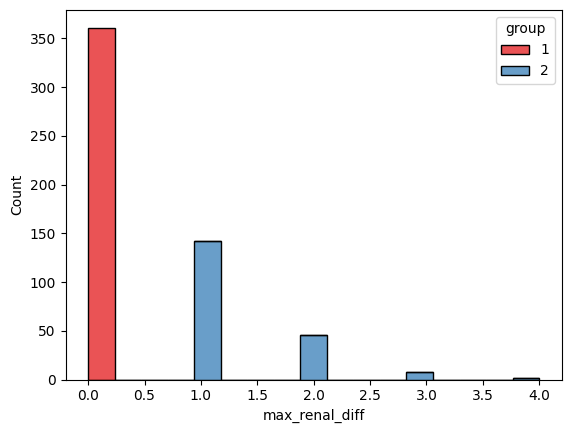

In [7]:
sns.histplot(
    design_matrix_train,
    x="max_renal_diff",
    hue="group",
    palette="Set1",
    multiple="stack"
)

In [8]:
design_matrix_train['group'].value_counts()

group
1    361
2    198
Name: count, dtype: int64

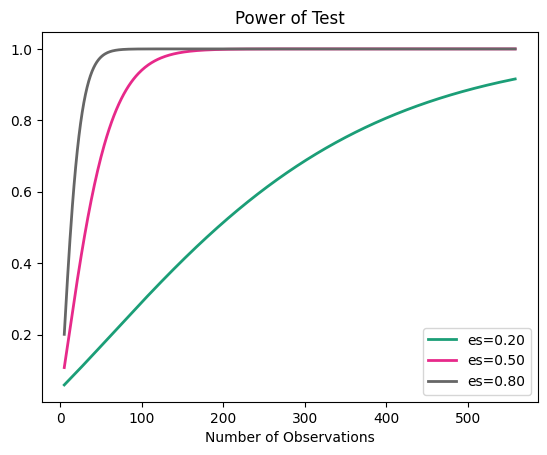

In [9]:
from statsmodels.stats.power import TTestIndPower
import matplotlib.pyplot as plt

# parameters for power analysis
effect_sizes = np.array([0.2, 0.5, 0.8])
sample_sizes = np.array(range(5, design_matrix_train.shape[0]))


analysis = TTestIndPower()

analysis.plot_power(dep_var='nobs', nobs=sample_sizes, effect_size=effect_sizes)
plt.show()

In [10]:
quant_matrix_train = preprocess_data(ms_data, design_matrix=design_matrix_train)

In [11]:
quant_matrix_train = quant_matrix_train.compare(
    method="linregress",
    comparisons=(2,1),
    min_samples_per_group=2,
    level="protein",
    multiple_testing_correction_method="fdr_tsbh"
)

In [12]:
quant_matrix_train.write("de_results/renal_de_proteins.tsv")

In [13]:
quant_matrix_de = quant_matrix_train.to_df()

<Axes: xlabel='Log2FoldChange2-1', ylabel='-Log10CorrectedPValue2-1'>

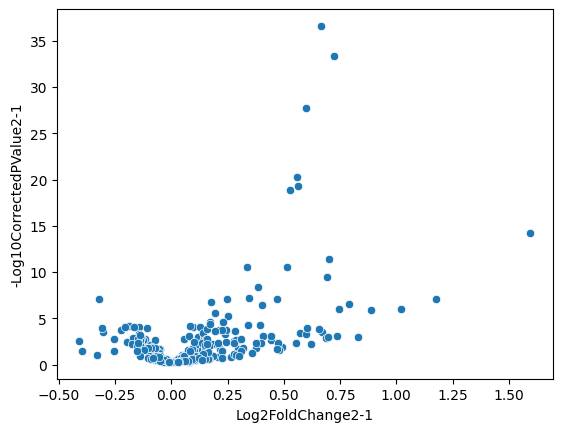

In [14]:
sns.scatterplot(
    data=quant_matrix_de,
    x="Log2FoldChange2-1",
    y="-Log10CorrectedPValue2-1"
)

In [15]:
qm_filtered = (
    
    QuantMatrix(
        quantification_file=quant_matrix_de,
        design_matrix_file=design_matrix_train
    )
    
)

In [16]:
training_data, y = qm_filtered.to_ml(feature_column="ProteinLabel")

In [17]:
protein_columns = training_data.columns.to_list()

In [18]:
len(protein_columns)

287

In [19]:
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.impute import SimpleImputer

X = training_data.copy()

protein_scaler = StandardScaler()

X[protein_columns] = protein_scaler.fit_transform(X[protein_columns])

X = X.copy()

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier


protein_clf = LogisticRegression(
    random_state=42,
    #penalty="l1",
    class_weight="balanced",
    #C=0.1,
    #solver="liblinear",
    max_iter=1000
)

# protein_clf = BaggingClassifier(
#     estimator=protein_clf,
#     random_state=42
# )

In [21]:
from cleanlab.filter import find_label_issues
from sklearn.model_selection import cross_val_predict

pred_probs = cross_val_predict(protein_clf, X, y.values.ravel(), cv=3, method="predict_proba")

label_issues = find_label_issues(
    labels=y.values.ravel(),
    pred_probs=pred_probs,
    return_indices_ranked_by='self_confidence'  # Ranks by likelihood of being mislabeled
)

/srv/data1/home/aaron/envs/miniconda3/envs/revisionenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [22]:
mask = np.ones(len(y.values.ravel()), dtype=bool)

mask[label_issues] = False

In [23]:
X = X.iloc[mask, :].copy()
y = y.iloc[mask, :].copy()

In [24]:
y['label'].value_counts()

label
0    278
1    123
Name: count, dtype: int64

In [25]:
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight


class_weight = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y.values.ravel()),
    y=y.values.ravel()
)

class_weight = dict(zip(np.unique(y.values.ravel()), class_weight))

class_weight

{0: 0.7212230215827338, 1: 1.6300813008130082}

In [26]:
# sample_weight = compute_sample_weight(
#     class_weight=class_weight,
#     y=y.values.ravel()
# )

In [27]:
len(protein_columns)

287

In [28]:
from mrmr import mrmr_classif
selected_proteins = mrmr_classif(X=X[protein_columns], y=y.values.ravel(), K=50)

100%|██████████| 50/50 [00:15<00:00,  3.20it/s]


In [29]:
selected_proteins

['CYTC_HUMAN',
 'FINC_HUMAN',
 'B2MG_HUMAN',
 'CFAD_HUMAN',
 'VSIG4_HUMAN',
 'LYSC_HUMAN',
 'THBG_HUMAN',
 'COIA1_HUMAN',
 'H4_HUMAN',
 'PTGDS_HUMAN',
 'FETUB_HUMAN',
 'TIMP1_HUMAN',
 'IBP7_HUMAN',
 'A2GL_HUMAN',
 'TAGL2_HUMAN',
 'VWF_HUMAN',
 'FBLN5_HUMAN',
 'LBP_HUMAN',
 'FBLN3_HUMAN',
 'SAA4_HUMAN',
 'SEPP1_HUMAN',
 'TSP1_HUMAN',
 'CATB_HUMAN',
 'IBP2_HUMAN',
 'NID1_HUMAN',
 'CBG_HUMAN',
 'CRP_HUMAN',
 'COMP_HUMAN',
 'CMGA_HUMAN',
 'CO6A3_HUMAN',
 'CATD_HUMAN',
 'PEDF_HUMAN',
 'CD44_HUMAN',
 'PROC_HUMAN',
 'BTD_HUMAN',
 'RNAS1_HUMAN',
 'VCAM1_HUMAN',
 'SAA2_HUMAN',
 'FCGBP_HUMAN',
 'PEBP4_HUMAN',
 'APOM_HUMAN',
 'CXCL7_HUMAN',
 'PROF1_HUMAN',
 'PTPRG_HUMAN',
 'SAA1_HUMAN',
 'RNAS4_HUMAN',
 'SODE_HUMAN',
 'LCAT_HUMAN',
 'CALR_HUMAN',
 'CD14_HUMAN']

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier


protein_clf = LogisticRegression(
    class_weight=class_weight,
    random_state=42
)

In [31]:
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_validate

cv = StratifiedKFold(3)
eval_result = cross_validate(
    protein_clf, X[selected_proteins], y.values.ravel(), scoring=("recall", "precision", "accuracy", "balanced_accuracy"), cv=cv, #params={"sample_weight": sample_weight}
)
eval_result['test_recall'].mean(), eval_result['test_precision'].mean(), eval_result['test_accuracy'].mean(), eval_result['test_balanced_accuracy'].mean()

(0.8130081300813008, 0.8292456335934597, 0.890322821980324, 0.8687722589007096)

In [32]:
from dpks.interpretation import BootstrapInterpreter

protein_interpreter = BootstrapInterpreter(
    n_iterations=100,
    feature_names=selected_proteins,
    downsample_background=True,
    shuffle_iterations=100
)

In [33]:
protein_interpreter.fit(X[selected_proteins].values, y.values.ravel(), protein_clf)

In [34]:
protein_importances = protein_interpreter.results_.sort_values("mean_importance", ascending=False)

In [35]:
protein_importances.head(20)

,feature,iteration_0_importance,iteration_0_rank,iteration_1_importance,iteration_1_rank,iteration_2_importance,iteration_2_rank,iteration_3_importance,iteration_3_rank,iteration_4_importance,...,iteration_98_importance,iteration_98_rank,iteration_99_importance,iteration_99_rank,mean_importance,median_importance,stdev_importance,mean_rank,median_rank,stdev_rank
0,CYTC_HUMAN,0.765045,2.0,0.585356,7.0,1.000000,1.0,1.000000,1.0,0.531965,...,0.822414,3.0,1.000000,1.0,0.822800,0.901453,0.219147,4.97,2.0,6.883526
42,PROF1_HUMAN,0.474491,12.0,0.677427,3.0,0.740762,3.0,0.741444,4.0,0.651544,...,0.979709,2.0,0.997958,2.0,0.698009,0.706198,0.196226,6.21,4.5,6.077438
18,FBLN3_HUMAN,1.000000,1.0,0.598715,6.0,0.707999,5.0,0.840688,2.0,0.315176,...,1.000000,1.0,0.553166,10.0,0.697047,0.687973,0.246119,7.64,5.0,8.396151
7,COIA1_HUMAN,0.621866,6.0,0.272681,18.0,0.539533,7.0,0.815283,3.0,1.000000,...,0.689530,9.0,0.977438,3.0,0.619333,0.626589,0.239526,10.02,9.0,7.945496
3,CFAD_HUMAN,0.267758,26.0,1.000000,1.0,0.307404,21.0,0.519306,8.0,0.842361,...,0.820759,4.0,0.529418,11.0,0.615948,0.617644,0.224800,9.89,7.0,7.914818
36,VCAM1_HUMAN,0.549378,10.0,0.442122,9.0,0.522067,9.0,0.720790,5.0,0.368833,...,0.565127,12.0,0.718175,7.0,0.598681,0.628724,0.218175,10.15,7.5,8.143132
11,TIMP1_HUMAN,0.616399,7.0,0.615204,5.0,0.784444,2.0,0.392403,14.0,0.512827,...,0.752836,7.0,0.268247,24.0,0.579432,0.580012,0.206925,10.60,8.0,7.797954
34,BTD_HUMAN,0.635391,5.0,0.217450,26.0,0.671944,6.0,0.514408,9.0,0.491868,...,0.358882,22.0,0.822569,5.0,0.557286,0.560541,0.215862,11.49,11.0,7.873360
8,H4_HUMAN,0.701788,4.0,0.345762,14.0,0.407086,14.0,0.507623,10.0,0.338625,...,0.777468,6.0,0.957151,4.0,0.545836,0.547204,0.223656,12.45,9.0,9.381235
2,B2MG_HUMAN,0.743773,3.0,0.210019,30.0,0.387273,16.0,0.399062,13.0,0.156337,...,0.004260,50.0,0.476791,15.0,0.483171,0.434404,0.242061,15.74,13.0,11.387234


In [36]:
selected_proteins = protein_importances.head(10)['feature'].to_list()

In [37]:
from dpks.interpretation import Classifier


protein_clf = Classifier(protein_clf)

In [38]:
selected_features = selected_proteins[:10]

In [39]:
for feature in selected_features:

    print(feature)

CYTC_HUMAN
PROF1_HUMAN
FBLN3_HUMAN
COIA1_HUMAN
CFAD_HUMAN
VCAM1_HUMAN
TIMP1_HUMAN
BTD_HUMAN
H4_HUMAN
B2MG_HUMAN


In [40]:
protein_clf = LogisticRegression(
    class_weight=class_weight,
    random_state=42
)

In [41]:
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_validate

cv = StratifiedKFold(3, shuffle=True, random_state=42)
eval_result = cross_validate(
    protein_clf, X[selected_features], y.values.ravel(), scoring=("recall", "precision", "accuracy", "balanced_accuracy"), cv=cv, #params={"sample_weight": sample_weight}
)
eval_result['test_recall'].mean(), eval_result['test_precision'].mean(), eval_result['test_accuracy'].mean(), eval_result['test_balanced_accuracy'].mean()

(0.7967479674796749,
 0.7063953488372093,
 0.8354468260202745,
 0.8246830066477383)

In [42]:
cv = StratifiedKFold(3, shuffle=True, random_state=42)
eval_result = cross_validate(
    protein_clf, X[protein_columns], y.values.ravel(), scoring=("recall", "precision", "accuracy", "balanced_accuracy"), cv=cv, #params={"sample_weight": sample_weight}
)
eval_result['test_recall'].mean(), eval_result['test_precision'].mean(), eval_result['test_accuracy'].mean(), eval_result['test_balanced_accuracy'].mean()

(0.8536585365853658, 0.875, 0.9177047095350316, 0.899850150324785)

In [43]:
from dpks.interpretation import BootstrapInterpreter

final_protein_interpreter = BootstrapInterpreter(
    n_iterations=100,
    feature_names=selected_features,
    downsample_background=True,
    shuffle_iterations=100
)

In [44]:
final_protein_interpreter.fit(X[selected_features].values, y.values.ravel(), protein_clf)

In [45]:
final_protein_importances = final_protein_interpreter.results_.sort_values("mean_importance", ascending=False)

In [46]:
final_protein_importances

,feature,iteration_0_importance,iteration_0_rank,iteration_1_importance,iteration_1_rank,iteration_2_importance,iteration_2_rank,iteration_3_importance,iteration_3_rank,iteration_4_importance,...,iteration_98_importance,iteration_98_rank,iteration_99_importance,iteration_99_rank,mean_importance,median_importance,stdev_importance,mean_rank,median_rank,stdev_rank
0,CYTC_HUMAN,1.000000,1.0,0.599557,3.0,1.000000,1.0,1.000000,1.0,1.000000,...,1.000000,1.0,1.000000,1.0,0.933477,1.000000,0.148810,1.54,1.0,1.298173
8,H4_HUMAN,0.523337,4.0,0.680648,2.0,0.347547,6.0,0.672498,3.0,0.693435,...,0.876028,2.0,0.819221,2.0,0.647388,0.635370,0.184528,2.77,2.5,1.062254
4,CFAD_HUMAN,0.046049,8.0,1.000000,1.0,0.687544,3.0,0.745700,2.0,0.668283,...,0.873838,3.0,0.711402,3.0,0.603234,0.616080,0.270134,3.50,3.0,1.941050
7,BTD_HUMAN,0.542245,3.0,0.415253,5.0,0.573598,4.0,0.561583,5.0,0.676543,...,0.514112,5.0,0.347438,6.0,0.479381,0.460984,0.141281,4.22,4.0,1.360184
3,COIA1_HUMAN,0.244046,6.0,0.066093,9.0,0.775814,2.0,0.585028,4.0,0.979355,...,0.342294,6.0,0.693103,4.0,0.432274,0.347710,0.270993,5.32,6.0,2.251285
1,PROF1_HUMAN,0.033695,9.0,0.513976,4.0,0.298118,7.0,0.398749,7.0,0.456202,...,0.571882,4.0,0.350750,5.0,0.345473,0.350193,0.140481,6.07,6.0,1.771007
9,B2MG_HUMAN,0.625576,2.0,0.130758,7.0,0.362636,5.0,0.398899,6.0,0.090545,...,0.104334,9.0,0.169125,8.0,0.235456,0.181346,0.194975,7.40,8.0,2.150875
2,FBLN3_HUMAN,0.455070,5.0,0.005875,10.0,0.118437,8.0,0.371816,8.0,0.296568,...,0.164098,8.0,0.091216,9.0,0.234007,0.242256,0.168119,7.49,8.0,2.027563
5,VCAM1_HUMAN,0.091614,7.0,0.227813,6.0,0.030977,9.0,0.148545,9.0,0.197355,...,0.041954,10.0,0.232396,7.0,0.187112,0.170323,0.142897,8.14,8.0,1.620699
6,TIMP1_HUMAN,0.014943,10.0,0.097359,8.0,0.001988,10.0,0.104812,10.0,0.054840,...,0.278415,7.0,0.047332,10.0,0.155863,0.120965,0.117522,8.55,9.0,1.351206


In [47]:
final_protein_importances.to_csv(
    "feature_importances/renal_protein_importances.tsv",
    sep="\t",
    index=False
)

# Model Testing

In [48]:
ms_data_test = pd.read_csv(
    "../0_data/proteins_test_filtered.tsv"
    , sep="\t"
)
design_matrix_test = pd.read_csv(
    "../0_data/design_matrix_test.tsv",
    sep='\t'
)

In [49]:
design_matrix_test = preprocess_design_matrix(design_matrix_test)

quant_matrix_test = preprocess_data(ms_data_test, design_matrix=design_matrix_test)

In [50]:
quant_matrix_test_df = quant_matrix_test.to_df()
#quant_matrix_test_df = quant_matrix_test_df[quant_matrix_test_df['ProteinLabel'].isin(selected_features)]

In [51]:
qm_filtered_test = (
    
    QuantMatrix(
        quantification_file=quant_matrix_test_df,
        design_matrix_file=design_matrix_test
    )
    
)

In [52]:
testing_data, y_test = qm_filtered_test.to_ml(feature_column="ProteinLabel")

In [53]:
X_test = testing_data.copy()

X_test[protein_scaler.feature_names_in_] = protein_scaler.transform(X_test[protein_scaler.feature_names_in_])

X_test = X_test.copy()

In [54]:
from sklearn.linear_model import LogisticRegression

from xgboost import XGBClassifier

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

decision_tree = DecisionTreeClassifier(random_state=42)
random_forest = RandomForestClassifier(random_state=42)
svc = SVC(random_state=42)
knn = KNeighborsClassifier()
naive_bayes = GaussianNB()
mlp = MLPClassifier(random_state=42)


lr_clf = LogisticRegression(
    class_weight=class_weight,
    random_state=42
)

# lr_clf = BaggingClassifier(
#     estimator=lr_clf,
#     random_state=42
# )

xgb_clf = XGBClassifier(
    max_depth=5,
    min_child_weight=5,
    gamma=0.1,
    reg_alpha=0.1,
    reg_lambda=1.0,
    learning_rate=0.01,
    n_estimators=1000,
    objective='binary:logistic',
    random_state=42,
    eval_metric='logloss',
    n_jobs=1
)

In [55]:
lr_clf.fit(X[selected_features], y.values.ravel()) #, )
xgb_clf.fit(X[selected_features], y.values.ravel(), )
decision_tree.fit(X[selected_features], y.values.ravel(), ) 
random_forest.fit(X[selected_features], y.values.ravel(), )
svc.fit(X[selected_features], y.values.ravel(), )
knn.fit(X[selected_features], y.values.ravel()) 
naive_bayes.fit(X[selected_features], y.values.ravel(), ) 
mlp.fit(X[selected_features], y.values.ravel())

MLPClassifier(random_state=42)

In [56]:
from sklearn.metrics import f1_score

lr_predictions = lr_clf.predict(X_test[selected_features])
lr_ba = f1_score(y_test.values.ravel(), lr_predictions)

xgb_predictions = xgb_clf.predict(X_test[selected_features])
xgb_ba = f1_score(y_test.values.ravel(), xgb_predictions)

decision_tree_predictions = decision_tree.predict(X_test[selected_features])
decision_tree_ba = f1_score(y_test.values.ravel(), decision_tree_predictions)

rf_predictions = random_forest.predict(X_test[selected_features])
rf_ba = f1_score(y_test.values.ravel(), rf_predictions)

svc_predictions = svc.predict(X_test[selected_features])
svc_ba = f1_score(y_test.values.ravel(), svc_predictions)

knn_predictions = knn.predict(X_test[selected_features])
knn_ba = f1_score(y_test.values.ravel(), knn_predictions)

nb_predictions = naive_bayes.predict(X_test[selected_features])
nb_ba = f1_score(y_test.values.ravel(), nb_predictions)

mlp_predictions = mlp.predict(X_test[selected_features])
mlp_ba = f1_score(y_test.values.ravel(), mlp_predictions)

In [57]:
lr_ba, xgb_ba, decision_tree_ba, rf_ba, svc_ba, knn_ba, nb_ba, mlp_ba

(0.6697459584295612,
 0.6361031518624641,
 0.6161879895561357,
 0.6556473829201102,
 0.65,
 0.6472148541114059,
 0.6650717703349283,
 0.6778846153846154)

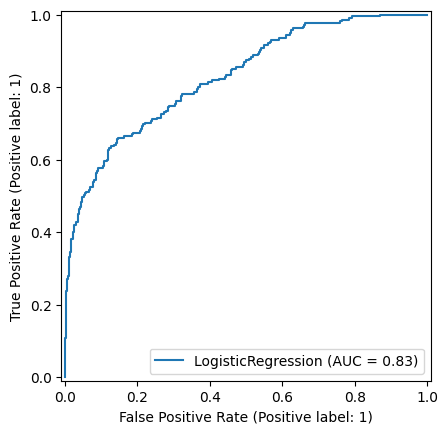

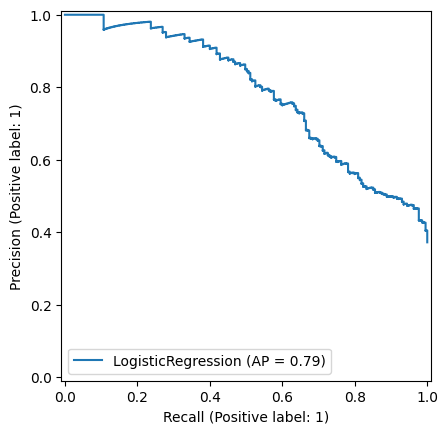

In [58]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

RocCurveDisplay.from_estimator(
    lr_clf, X_test[selected_features], y_test.values.ravel()
)


PrecisionRecallDisplay.from_estimator(
    lr_clf, X_test[selected_features], y_test.values.ravel()
)





In [59]:
from sklearn.metrics import roc_curve

y_probs = lr_clf.predict_proba(X_test[selected_features])[:, 1]

# Compute ROC curve metrics
fpr, tpr, thresholds = roc_curve( y_test.values.ravel(), y_probs)

# Create a DataFrame to store the metrics
roc_df = pd.DataFrame({
    'False Positive Rate': fpr,
    'True Positive Rate': tpr,
    'Threshold': thresholds
})


In [60]:
roc_df.to_csv(
    "roc/renal.tsv",
    sep="\t"
)

# Probability Prediction

In [61]:
design_matrix_test = pd.read_csv(
    "../0_data/design_matrix_test.tsv",
    sep='\t'
)

design_matrix_test['sample'] = design_matrix_test['injection']
design_matrix_test['group'] = 1

quant_matrix_predict = QuantMatrix(
    quantification_file=ms_data_test,
    design_matrix_file=design_matrix_test,
    annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
).impute(method="uniform_percentile", percentile=0.01)

predict_data, y_test_alll = quant_matrix_predict.to_ml(feature_column="ProteinLabel")

In [62]:
predict_data = predict_data[protein_columns].copy()

In [63]:
predict_data[protein_columns] = protein_scaler.transform(predict_data[protein_columns])

In [64]:
predict_data['renal_probability'] = lr_clf.predict_proba(predict_data[selected_features])[:, 1]

In [65]:
design_matrix_test = design_matrix_test.set_index("injection").join(
    predict_data['renal_probability']
).reset_index()

In [66]:
predict_data[['renal_probability']].to_csv(
    "predictions_test/renal.tsv",
    sep="\t"
)

<Axes: xlabel='renal_probability', ylabel='Count'>

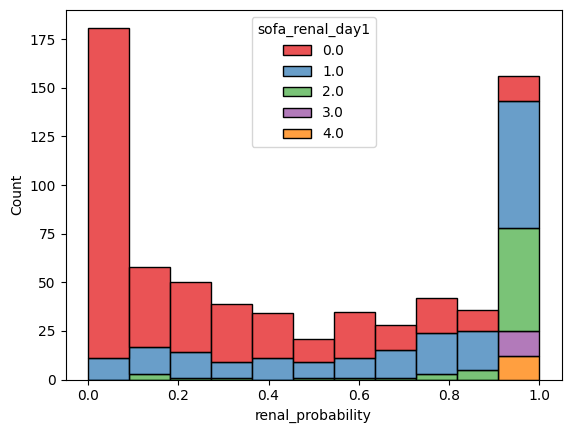

In [67]:
sns.histplot(
    data=design_matrix_test,
    x="renal_probability",
    hue="sofa_renal_day1",
    palette="Set1", 
    #kde=True,
    multiple="stack"
)

In [68]:
ms_data_val = pd.read_csv(
    "../0_data/proteins_val_filtered.tsv"
    , sep="\t"
)

design_matrix_val = pd.read_csv(
    "../0_data/design_matrix_validation.tsv",
    sep='\t'
)

design_matrix_val['sample'] = design_matrix_val['injection']
design_matrix_val['group'] = 1

quant_matrix_val = QuantMatrix(
    quantification_file=ms_data_val,
    design_matrix_file=design_matrix_val,
    annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
)

val_data, y_val = quant_matrix_val.to_ml(feature_column="ProteinLabel")

In [69]:
val_data = val_data[protein_columns].copy()

In [70]:
val_data[protein_columns] = protein_scaler.transform(val_data[protein_columns])

In [71]:
val_data['renal_probability'] = lr_clf.predict_proba(val_data[selected_features])[:, 1]

In [72]:
design_matrix_val = design_matrix_val.set_index("injection").join(
    val_data['renal_probability']
).reset_index()

In [73]:
val_data[['renal_probability']].to_csv(
    "predictions_val/renal.tsv",
    sep="\t"
)

<Axes: xlabel='renal_probability', ylabel='Count'>

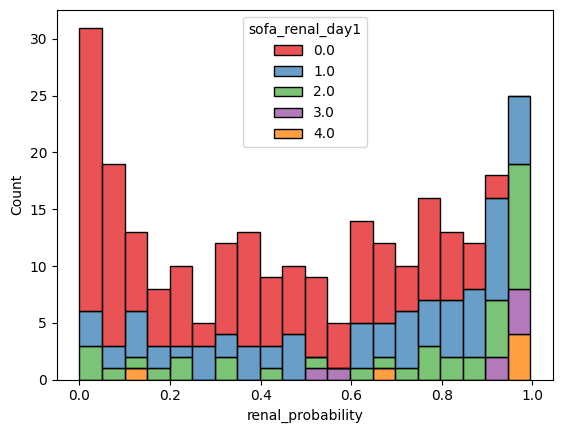

In [74]:
sns.histplot(
    data=design_matrix_val,
    x="renal_probability",
    hue="sofa_renal_day1",
    palette="Set1", 
    #kde=True,
    multiple="stack", 
    bins=20
)

In [75]:
val_data

,FIBA_HUMAN,TRFE_HUMAN,CFAH_HUMAN,CERU_HUMAN,GELS_HUMAN,VWF_HUMAN,CO7_HUMAN,A2MG_HUMAN,HPT_HUMAN,A2AP_HUMAN,...,LIRB1_HUMAN,EPCR_HUMAN,ADA2_HUMAN,MA2A1_HUMAN,PTPRG_HUMAN,FUCO_HUMAN,LAMP2_HUMAN,EIF3M_HUMAN,ACTB_HUMAN,renal_probability
SA_BOX1_1560_S1-G1_1_4421,-0.158417,0.509310,0.699778,0.393011,0.648473,0.143483,0.782717,0.852105,-0.204378,-0.121618,...,0.746596,0.666141,0.954150,0.757842,0.717647,0.955667,0.284339,1.313453,0.052772,0.878383
SA_BOX1_1679_S1-G10_1_4494,0.291403,0.515325,0.539522,0.733253,0.692496,-1.219093,0.184151,-0.038484,-0.550769,0.173276,...,0.341806,-1.592306,0.493832,0.486769,0.777347,0.620007,-0.356553,1.177632,0.380788,0.606191
SA_BOX1_1765_S1-D1_1_4418,0.755355,0.628183,0.361336,0.343028,0.916245,1.550597,0.822362,0.446039,0.300207,0.486642,...,0.961663,0.256295,0.484027,0.264945,0.890504,-0.665292,0.771457,0.487767,0.359267,0.894106
SA_BOX1_1785_S1-C11_1_4498,-0.103806,-0.469555,0.371392,0.367321,0.099266,-1.166185,-0.176907,0.188495,-0.041683,0.342875,...,-0.228425,-1.177993,-0.046007,0.026696,0.464644,0.477002,-0.273191,0.283092,-0.271680,0.034942
SA_BOX1_1791_S1-G11_1_4502,-0.371213,0.587952,0.490601,-0.143010,0.708966,-1.036660,0.413313,0.552134,-0.741201,0.067707,...,0.959464,-1.377348,0.553788,0.338191,0.414719,0.610250,0.222154,1.593269,-0.223780,0.183368
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SA_BOX1_1209_S1-F5_1_4452,-4.249992,-2.271368,-4.658107,1.313773,-4.028478,-1.236022,-4.948146,0.626514,-3.241737,-4.625131,...,-1.688033,-1.523364,-2.588318,-2.709000,-2.881809,-1.847721,-2.409028,-4.310504,-4.175930,0.000296
SA_BOX1_1355_S1-F8_1_4477,-4.158850,-0.763324,-4.585953,-6.687143,-4.211432,-1.285827,-4.367142,-0.011912,1.096018,-4.600431,...,-1.799793,-1.327424,-2.544126,-2.575131,-3.518689,-1.678173,-2.206997,-3.935871,-4.498001,0.000315
SA_BOX1_1924_S1-F9_1_4485,-4.483643,-1.132605,-4.710954,2.062236,-4.379897,-1.006831,-4.575290,-1.377441,-3.355217,-4.648288,...,-1.977525,-1.593098,-2.575424,-2.880733,-2.904148,-2.080040,-2.282397,-4.123399,-4.226254,0.000345
SA_BOX1_1022_S1-F4_1_4444,-4.438655,-0.989596,-4.438603,1.765572,-4.441031,-1.238002,-4.730771,-9.332197,-2.970760,-4.489237,...,-1.971893,-1.128991,-2.541594,-2.488923,-3.505792,-1.933249,-2.377880,-3.938520,-4.468900,0.000135


In [76]:
X

,FIBA_HUMAN,TRFE_HUMAN,CFAH_HUMAN,CERU_HUMAN,GELS_HUMAN,VWF_HUMAN,CO7_HUMAN,A2MG_HUMAN,HPT_HUMAN,A2AP_HUMAN,...,IL1AP_HUMAN,LIRB1_HUMAN,EPCR_HUMAN,ADA2_HUMAN,MA2A1_HUMAN,PTPRG_HUMAN,FUCO_HUMAN,LAMP2_HUMAN,EIF3M_HUMAN,ACTB_HUMAN
SA_BOX_1-462_S1-C8_1_6848,-1.029013,0.713367,-1.328853,-0.166896,0.447192,-1.141389,-2.612304,-0.475017,-0.793517,1.892094,...,1.905953,0.027820,-1.209752,-0.067367,0.734985,0.279562,0.861290,0.709511,0.136157,-1.160169
SA_BOX_3-2442_S4-H8_1_5579,-0.209121,0.331724,1.177964,0.666625,0.023964,-0.148500,-0.096344,1.338294,0.145690,1.227016,...,-1.031156,0.532986,0.290341,0.547096,0.769534,0.107317,0.874127,-0.127102,0.339929,-0.206521
SA_BOX_2-1644_S2-A10_1_6960,0.923198,0.566673,-0.607061,-0.779773,0.428512,0.255162,0.039559,0.365559,0.185131,0.011698,...,-0.251828,0.258662,-1.339163,0.043038,0.549407,0.475503,0.624000,0.043692,0.200749,0.157905
SA_BOX_4-2435_S5-E11_1_5698,-0.936945,0.775633,1.227339,-0.710150,1.757199,1.070997,-0.243344,0.453851,-0.779052,-0.659903,...,0.616093,0.590208,0.496207,0.015935,0.910850,0.711553,0.664640,0.275023,1.136742,-0.818569
SA_BOX_15-57_S4-A1_1_6692,-0.644859,0.643251,-0.268357,0.957839,0.231601,-1.279872,-0.612247,-0.960785,0.338250,-1.321050,...,-0.959180,0.338628,-1.159773,-0.290905,0.364722,0.535279,0.408476,0.850685,-1.039421,0.729397
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
SA_BOX_6-746_S2-E6_1_5853,-0.229775,0.706158,0.820180,-0.781554,0.928844,-0.970559,-0.553941,-1.280845,-0.079817,-0.439190,...,0.840774,0.208285,-1.297727,-3.775989,-0.125710,-0.030165,-2.092781,-0.941599,0.908237,0.746567
SA_BOX_13-389_S1-B6_1_6537,-0.426250,0.434033,-1.293972,-0.430434,0.474890,-1.268688,-0.328737,0.106827,-0.767902,-0.278661,...,1.553373,-2.830727,0.960655,0.839631,-0.289981,-0.494222,0.703821,0.832210,-0.176447,1.205952
SA_BOX_14-2043_S2-A2_1_6602,-1.002535,0.619702,-0.203770,-0.366891,0.925423,-0.218537,0.269735,-0.433323,0.313643,-1.377603,...,-1.708970,0.205434,0.887132,-0.178274,-1.250582,-0.135065,-1.694800,0.150637,0.377837,0.095061
SA_BOX_11-2056_S4-F8_1_6362,1.071377,-0.548864,0.579702,0.911484,0.384807,-1.009959,0.028006,0.047774,0.279770,0.485964,...,0.367952,0.303974,-1.369144,-0.256926,0.470032,0.305068,0.423581,0.414006,0.293072,0.836016


In [77]:
ms_data_hero = pd.read_csv(
    "../0_data/proteins_hero_filtered.tsv"
    , sep="\t"
)

design_matrix_hero = pd.read_csv(
    "../0_data/design_matrix_hero.tsv",
    sep='\t'
)

design_matrix_hero['sample'] = design_matrix_hero['injection']
design_matrix_hero['group'] = 1

quant_matrix_hero = QuantMatrix(
    quantification_file=ms_data_hero,
    design_matrix_file=design_matrix_hero,
    annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
)

hero_data, y_hero = quant_matrix_hero.to_ml(feature_column="ProteinLabel")

In [78]:
hero_data = hero_data[protein_columns].copy()

In [79]:
hero_data[protein_columns] = protein_scaler.transform(hero_data[protein_columns])

In [80]:
hero_data['renal_probability'] = lr_clf.predict_proba(hero_data[selected_features])[:, 1]

In [81]:
design_matrix_hero = design_matrix_hero.set_index("injection").join(
    hero_data['renal_probability']
).reset_index()

In [82]:
hero_data[['renal_probability']].to_csv(
    "predictions_external/renal.tsv",
    sep="\t"
)

<Axes: xlabel='renal_probability', ylabel='Count'>

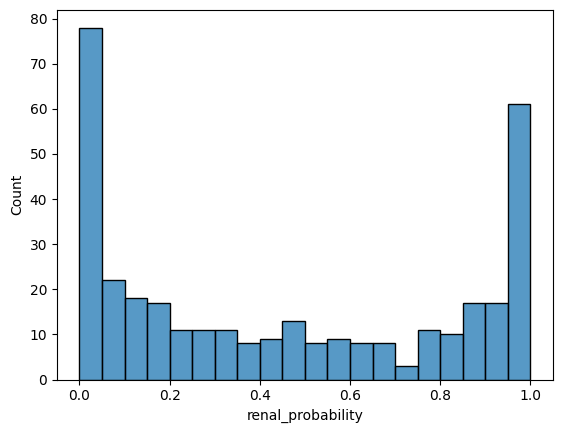

In [83]:
sns.histplot(
    data=hero_data,
    x="renal_probability",
    #hue="sofa_renal_day1",
    palette="Set1", 
    #kde=True,
    multiple="stack", 
    bins=20
)

In [84]:
hero_check = hero_data[protein_columns]
hero_check['Dataset'] = "Hero"

In [85]:
test_check = X_test[protein_columns]
test_check['Dataset'] = "Test"

In [86]:
train_check = X[protein_columns]
train_check['Dataset'] = "Train"

In [87]:
val_check = val_data[protein_columns]
val_check['Dataset'] = "Val"

In [88]:
combined_check = pd.concat(
    [
        hero_check, 
        test_check, 
        train_check, 
        val_check
    ]
)

In [89]:
from umap import UMAP

reducer = UMAP(n_components=2)

components = reducer.fit_transform(
    combined_check[protein_columns]
)

In [90]:
combined_check['UMAP 1'] = components[:, 0]
combined_check['UMAP 2'] = components[:, 1]

<Axes: xlabel='UMAP 1', ylabel='UMAP 2'>

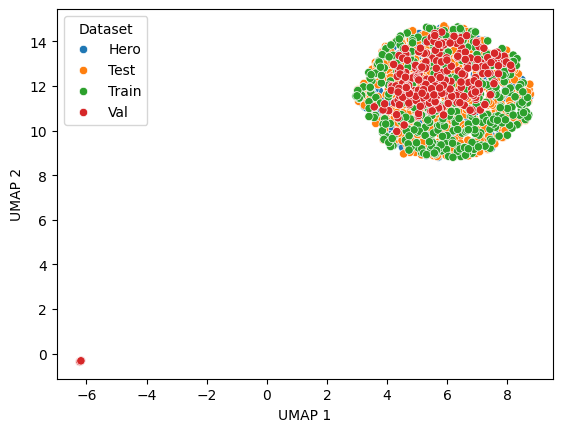

In [91]:
sns.scatterplot(
    data=combined_check,
    x="UMAP 1",
    y="UMAP 2",
    hue="Dataset"
)

In [92]:
from joblib import dump


with open("models/renal_protein_model.pkl", "wb") as f:

    dump(lr_clf, f)

with open("models/renal_protein_scaler.pkl", "wb") as f:

    dump(protein_scaler, f)
